**1. Import Liblary**



In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import joblib

plt.style.use('default')

**2. Load Dataset**

In [6]:
df = pd.read_csv("data_banjir_combine_final.csv")

print(df.shape)

df.head()

(18047, 17)


,NAME_2,NAME_3,avg_rainfall,max_rainfall,avg_temperature,elevation,landcover_class,ndvi,slope,soil_moisture,year,month,banjir,lat,long,map_image,NAME_3_clean
0,bogor,babakanmadang,64.775,124.032,28.76,501.913,Tree cover,0.564,5.001,39.583,2020,1,1,-6.5917,106.9020,RGB_BabakanMadang2020.tif,babakanmadang
1,bogor,bojonggede,68.241,128.949,32.89,133.589,Built-up,0.429,0.293,40.414,2020,1,1,-6.4774,106.7927,RGB_BabakanMadang2020.tif,bojonggede
2,bogor,caringin,56.423,92.324,29.93,765.651,Tree cover,0.513,4.954,39.662,2020,1,0,-6.7366,106.8660,RGB_Caringin2020(2).tif,caringin
3,bogor,cariu,60.034,98.129,30.02,143.845,Tree cover,0.652,2.107,39.014,2020,1,0,-6.5273,107.1371,RGB_BabakanMadang2020.tif,cariu
4,bogor,ciampea,66.380,133.877,30.27,212.619,Tree cover,0.569,1.340,39.658,2020,1,0,-6.5742,106.6980,RGB_Ciampea2020.tif,ciampea


**3. Informasi Dataset**

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18047 entries, 0 to 18046
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NAME_2           18047 non-null  object 
 1   NAME_3           18047 non-null  object 
 2   avg_rainfall     18047 non-null  float64
 3   max_rainfall     18047 non-null  float64
 4   avg_temperature  18047 non-null  float64
 5   elevation        18047 non-null  float64
 6   landcover_class  18047 non-null  object 
 7   ndvi             18047 non-null  float64
 8   slope            18047 non-null  float64
 9   soil_moisture    18047 non-null  float64
 10  year             18047 non-null  int64  
 11  month            18047 non-null  int64  
 12  banjir           18047 non-null  int64  
 13  lat              18047 non-null  float64
 14  long             18047 non-null  float64
 15  map_image        18047 non-null  object 
 16  NAME_3_clean     10980 non-null  object 
dtypes: float64(9

In [8]:
df.describe()

,avg_rainfall,max_rainfall,avg_temperature,elevation,ndvi,slope,soil_moisture,year,month,banjir,lat,long
count,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000
mean,44.969022,83.676593,32.182496,155.967521,0.491865,1.391249,36.306754,2022.100848,6.330747,0.438411,-5.143793,108.072618
std,25.480935,44.370820,4.676819,256.414214,0.181190,2.164682,3.911832,1.390713,3.680336,0.496206,3.042102,5.244815
min,0.525000,0.858000,11.490000,0.000000,0.082000,0.000000,13.210000,2020.000000,1.000000,0.000000,-10.855200,95.241700
25%,25.171000,52.819000,28.500000,13.259000,0.346000,0.127000,34.331000,2021.000000,3.000000,0.000000,-6.521700,106.631100
50%,42.294000,77.859000,31.660000,43.009000,0.489000,0.278000,37.386000,2022.000000,6.000000,0.000000,-6.251600,106.850900
75%,60.995500,108.645500,36.217500,164.829000,0.643000,1.745000,38.758000,2023.000000,10.000000,1.000000,-6.087800,107.853100
max,222.600000,386.707000,43.830000,1814.735000,0.891000,12.015000,42.898000,2024.000000,12.000000,1.000000,5.586300,140.652000


**4. Missing Value**

In [9]:
missing = df.isnull().sum()

missing

,0
NAME_2,0
NAME_3,0
avg_rainfall,0
max_rainfall,0
avg_temperature,0
elevation,0
landcover_class,0
ndvi,0
slope,0
soil_moisture,0


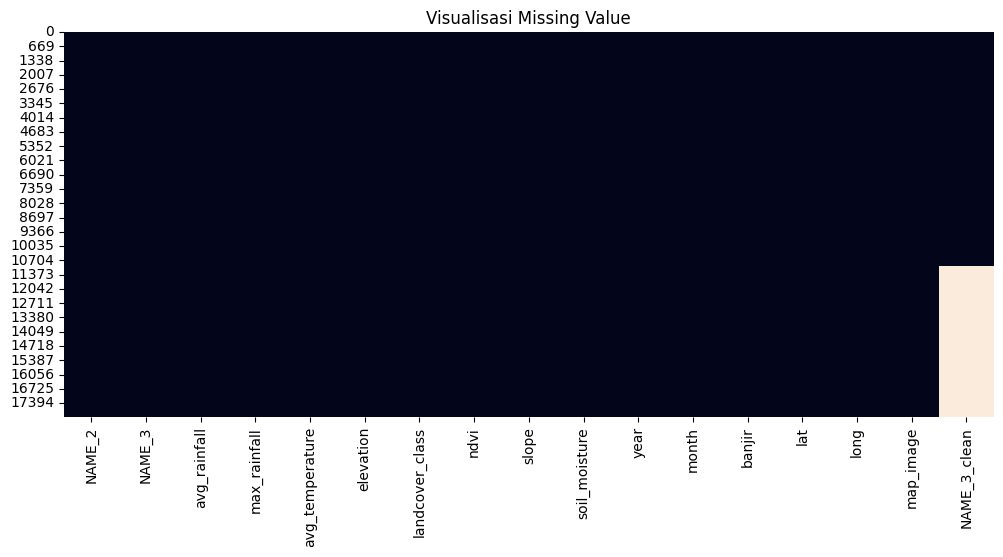

In [10]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Visualisasi Missing Value")

plt.show()

**5. Data Duplikat**

In [11]:
duplicate = df.duplicated().sum()

print("Jumlah Duplikat :", duplicate)

Jumlah Duplikat : 0


In [12]:
df = df.drop_duplicates()

**6. Distribusi Kelas**

In [13]:
df['banjir'].value_counts()

,count
banjir,
0,10135
1,7912


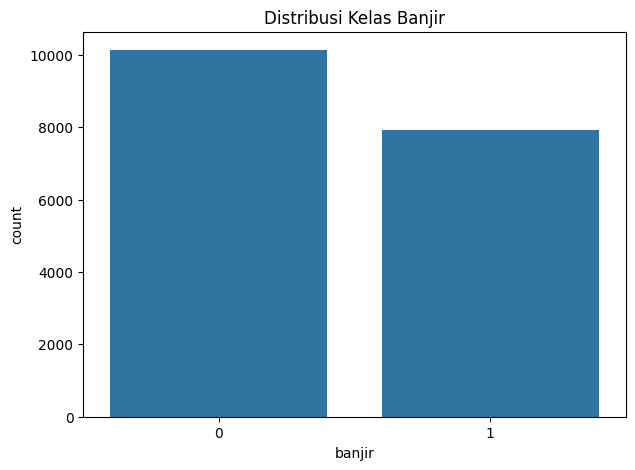

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='banjir'
)

plt.title("Distribusi Kelas Banjir")

plt.show()

In [15]:
(df['banjir'].value_counts(normalize=True)*100)

,proportion
banjir,
0,56.158918
1,43.841082


**7. Encoding Landcover**

In [16]:
le = LabelEncoder()

df['landcover_class'] = le.fit_transform(
    df['landcover_class']
)

In [17]:
mapping = dict(
    zip(
        le.classes_,
        le.transform(le.classes_)
    )
)

mapping

{'Built-Up': np.int64(0),
 'Built-up': np.int64(1),
 'Cropland': np.int64(2),
 'Grassland': np.int64(3),
 'Herbaceous Wetland': np.int64(4),
 'Mangroves': np.int64(5),
 'Permanent Water Bodies': np.int64(6),
 'Permanent water bodies': np.int64(7),
 'Tree Cover': np.int64(8),
 'Tree cover': np.int64(9),
 'Unknown': np.int64(10)}

**8. Statistik Deskriptif**

In [18]:
df.describe()

,avg_rainfall,max_rainfall,avg_temperature,elevation,landcover_class,ndvi,slope,soil_moisture,year,month,banjir,lat,long
count,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000,18047.000000
mean,44.969022,83.676593,32.182496,155.967521,5.616003,0.491865,1.391249,36.306754,2022.100848,6.330747,0.438411,-5.143793,108.072618
std,25.480935,44.370820,4.676819,256.414214,4.001502,0.181190,2.164682,3.911832,1.390713,3.680336,0.496206,3.042102,5.244815
min,0.525000,0.858000,11.490000,0.000000,0.000000,0.082000,0.000000,13.210000,2020.000000,1.000000,0.000000,-10.855200,95.241700
25%,25.171000,52.819000,28.500000,13.259000,1.000000,0.346000,0.127000,34.331000,2021.000000,3.000000,0.000000,-6.521700,106.631100
50%,42.294000,77.859000,31.660000,43.009000,8.000000,0.489000,0.278000,37.386000,2022.000000,6.000000,0.000000,-6.251600,106.850900
75%,60.995500,108.645500,36.217500,164.829000,9.000000,0.643000,1.745000,38.758000,2023.000000,10.000000,1.000000,-6.087800,107.853100
max,222.600000,386.707000,43.830000,1814.735000,10.000000,0.891000,12.015000,42.898000,2024.000000,12.000000,1.000000,5.586300,140.652000


**9. Heatmap Korelasi**

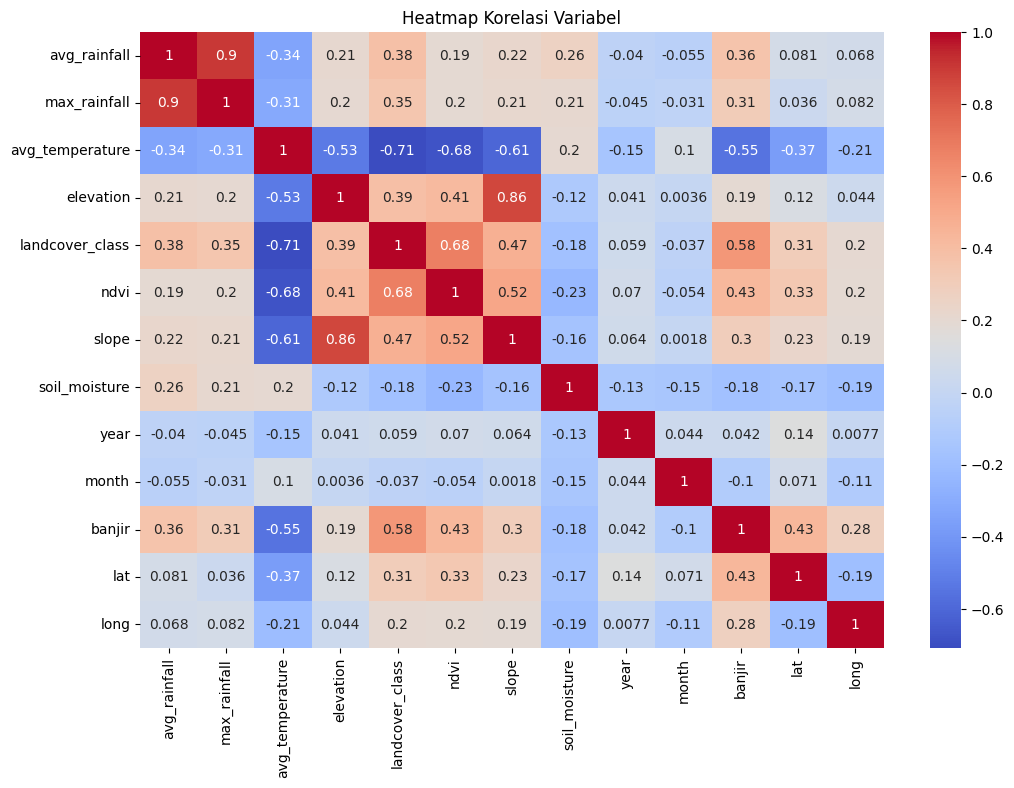

In [19]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Heatmap Korelasi Variabel"
)

plt.show()

**10. Distribusi Variabel Numerik**

In [20]:
numerical = [
    'avg_rainfall',
    'max_rainfall',
    'avg_temperature',
    'elevation',
    'ndvi',
    'slope',
    'soil_moisture'
]

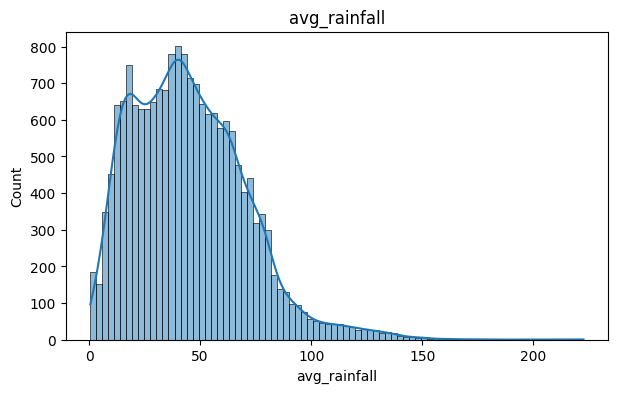

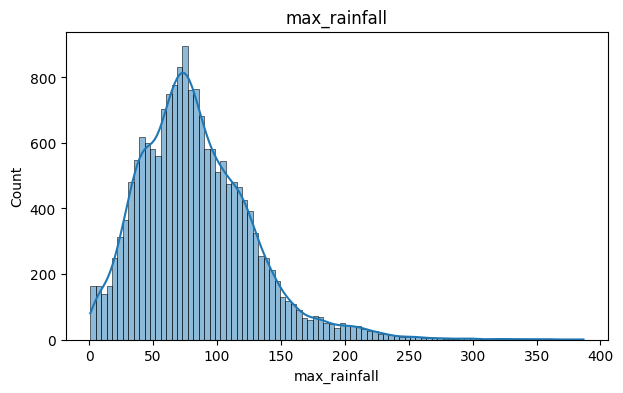

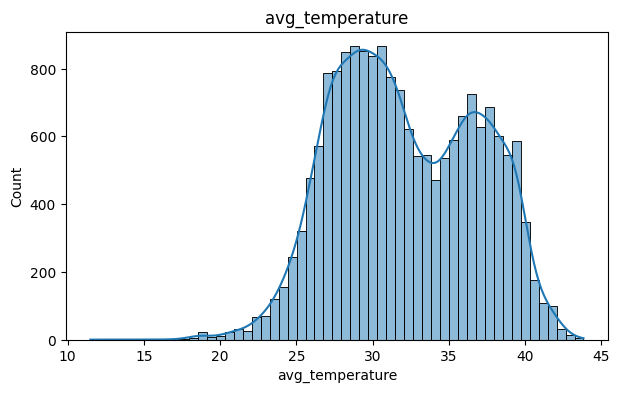

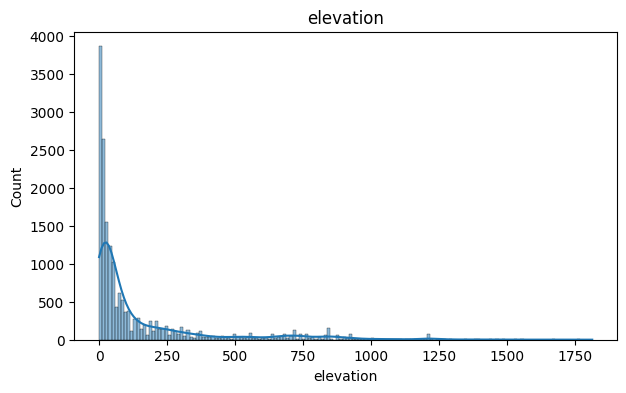

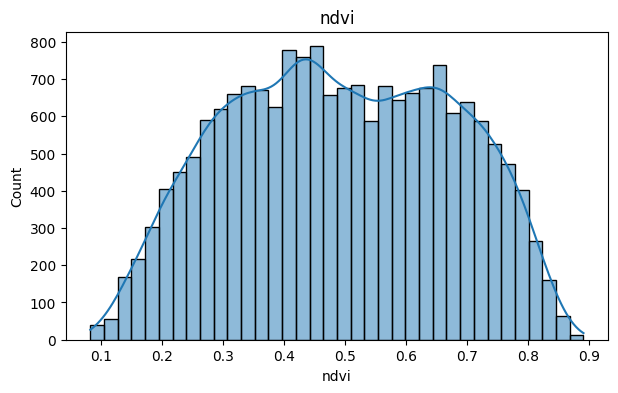

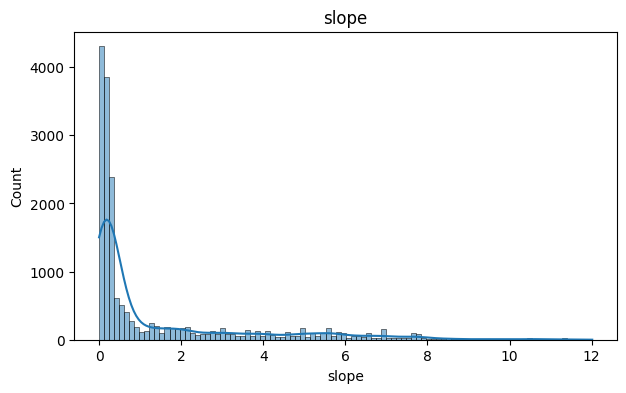

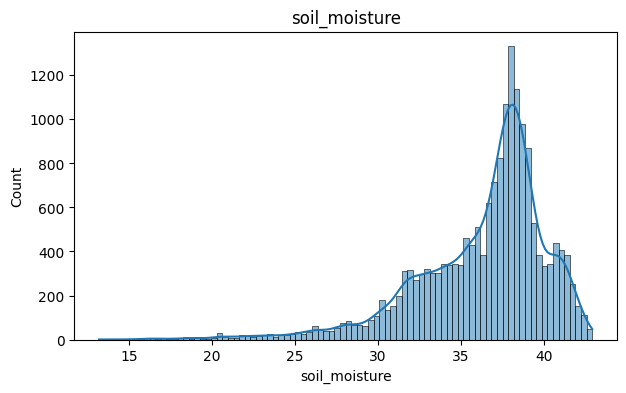

In [21]:
for col in numerical:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

**11. Boxplot**

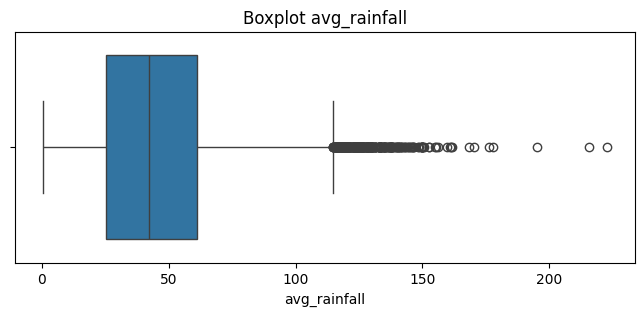

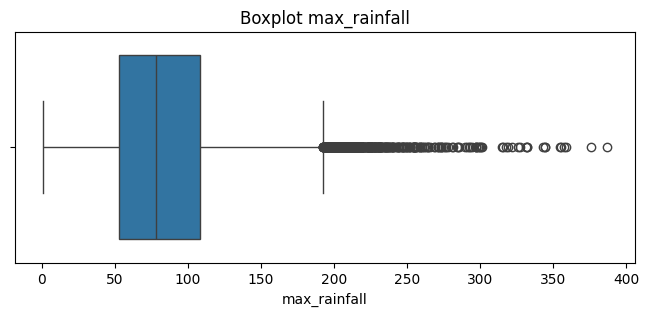

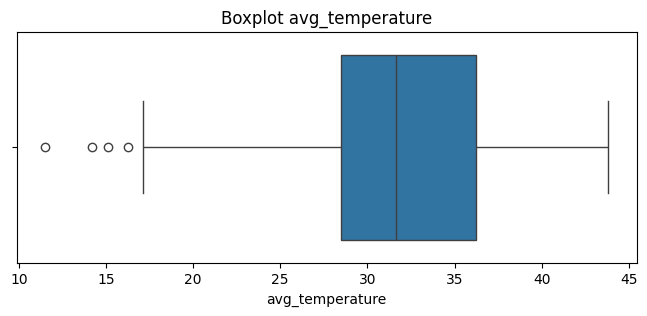

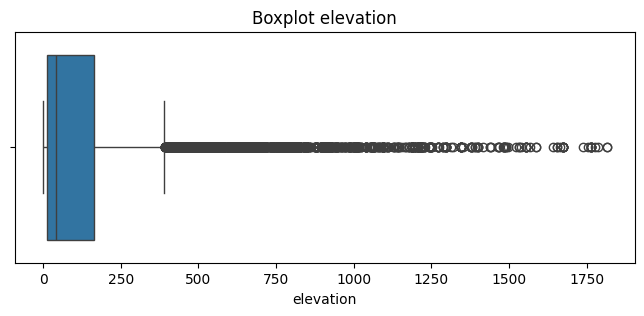

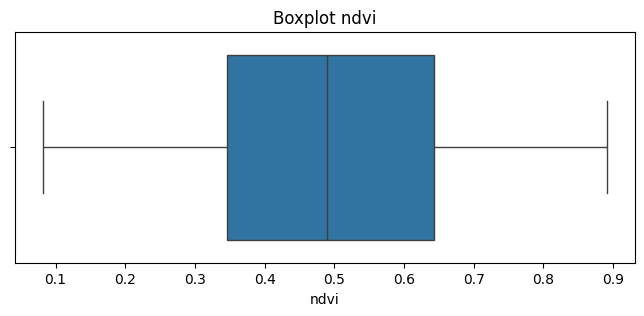

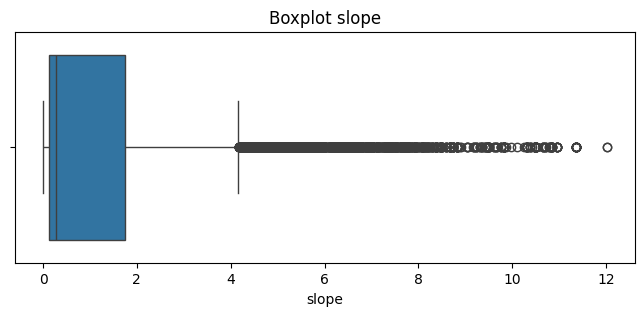

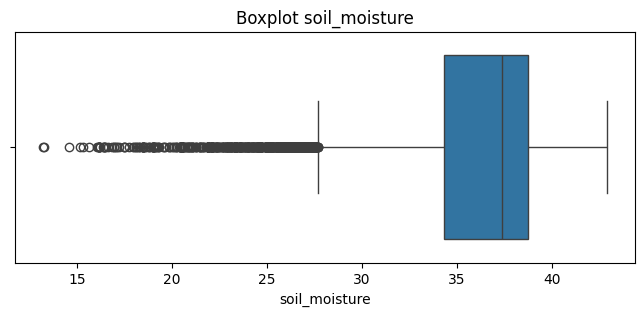

In [22]:
for col in numerical:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(
        f"Boxplot {col}"
    )

    plt.show()

**12. Seleksi Fitur**

In [46]:
X = df[
[
    'avg_rainfall',
    'max_rainfall',
    'avg_temperature',
    'elevation',
    'landcover_class',
    'ndvi',
    'slope',
    'soil_moisture'
]
]

y = df['banjir']

In [47]:
X.columns

Index(['avg_rainfall', 'max_rainfall', 'avg_temperature', 'elevation',
       'landcover_class', 'ndvi', 'slope', 'soil_moisture'],
      dtype='object')

**14. Split Data**

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
print(X_train.shape)
print(X_test.shape)

(14437, 8)
(3610, 8)


**15. Hyperparameter Tuning**

In [50]:
param_grid = {

    'n_estimators':[100,200,300],

    'max_depth':[10,15,20],

    'min_samples_split':[2,5,10],

    'min_samples_leaf':[1,2,4]
}

In [51]:
rf = RandomForestClassifier(
    random_state=42
)

grid = GridSearchCV(

    rf,

    param_grid,

    cv=5,

    scoring='f1',

    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 15, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [52]:
grid.best_params_

{'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

**16. Model Terbaik**

In [53]:
best_rf = grid.best_estimator_

**17. Training**

In [57]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

**18. Prediksi**

In [58]:
y_pred = best_rf.predict(
    X_test
)

y_prob = best_rf.predict_proba(
    X_test
)[:,1]

**19. Confusion Matrix**

In [59]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[2012,   15],
       [ 154, 1429]])

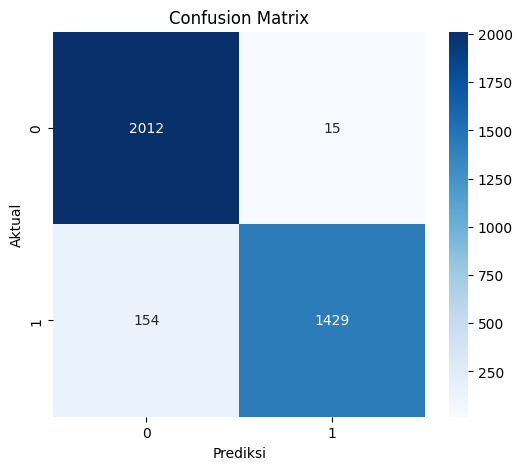

In [60]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Prediksi")

plt.ylabel("Aktual")

plt.title("Confusion Matrix")

plt.show()

**20. Evaluasi**

In [61]:
acc = accuracy_score(
    y_test,
    y_pred
)

prec = precision_score(
    y_test,
    y_pred
)

rec = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

In [65]:
print("Accuracy :",acc)
print("Precision:",prec)
print("Recall   :",rec)
print("F1 Score :",f1)
print("ROC AUC  :",auc)

Accuracy : 0.9531855955678671
Precision: 0.989612188365651
Recall   : 0.9027163613392293
F1 Score : 0.9441691443673604
ROC AUC  : 0.9839144075511236


**21. Classification Report**

In [67]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      2027
           1       0.99      0.90      0.94      1583

    accuracy                           0.95      3610
   macro avg       0.96      0.95      0.95      3610
weighted avg       0.96      0.95      0.95      3610



**22. ROC Curve**

In [68]:
fpr,tpr,thresholds = roc_curve(
    y_test,
    y_prob
)

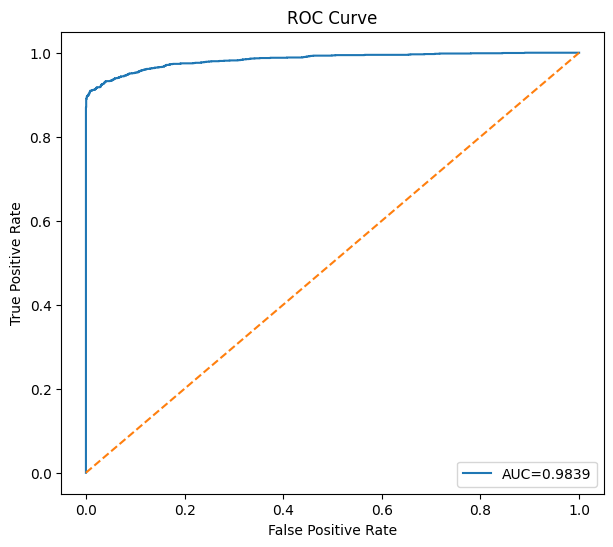

In [69]:
plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

23. Feature Importance

In [70]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':
    best_rf.feature_importances_

})

In [71]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
4,landcover_class,0.384810
2,avg_temperature,0.202747
6,slope,0.082978
0,avg_rainfall,0.075229
5,ndvi,0.072267
3,elevation,0.064500
7,soil_moisture,0.064147
1,max_rainfall,0.053322


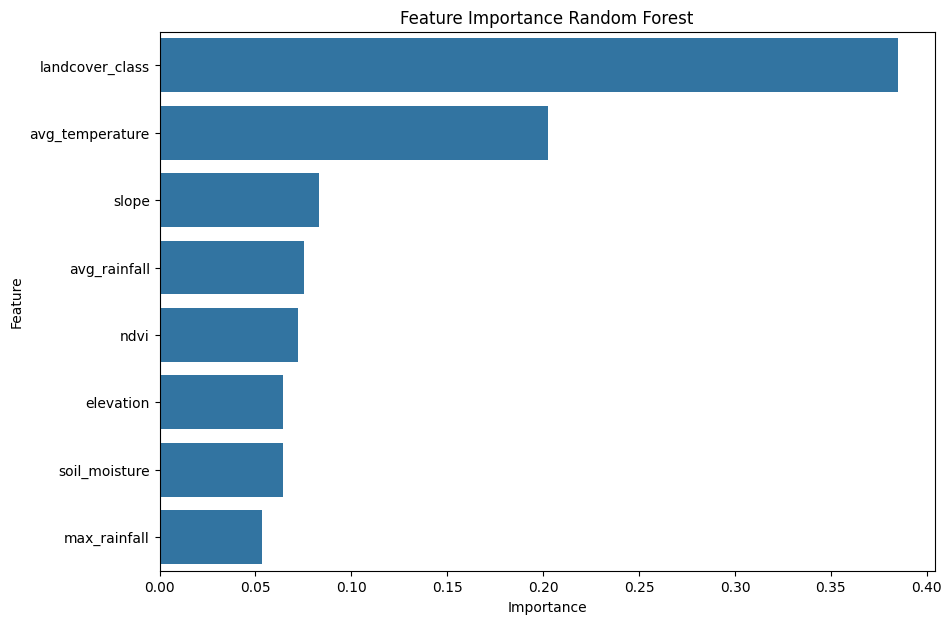

In [72]:
plt.figure(figsize=(10,7))

sns.barplot(

    data=importance,

    x='Importance',

    y='Feature'

)

plt.title(
    "Feature Importance Random Forest"
)

plt.show()

In [73]:
train_acc = accuracy_score(
    y_train,
    best_rf.predict(X_train)
)

test_acc = accuracy_score(
    y_test,
    best_rf.predict(X_test)
)

print("Training :", train_acc)
print("Testing  :", test_acc)
print("Gap      :", train_acc - test_acc)

Training : 0.9822677841656854
Testing  : 0.9531855955678671
Gap      : 0.029082188597818304


In [75]:
importance.head(12)

,Feature,Importance
4,landcover_class,0.384810
2,avg_temperature,0.202747
6,slope,0.082978
0,avg_rainfall,0.075229
5,ndvi,0.072267
3,elevation,0.064500
7,soil_moisture,0.064147
1,max_rainfall,0.053322


In [76]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
4,landcover_class,0.374614
2,avg_temperature,0.186340
6,slope,0.093395
5,ndvi,0.078851
0,avg_rainfall,0.076332
7,soil_moisture,0.065961
3,elevation,0.064940
1,max_rainfall,0.059567


Simpan Model Final

In [77]:
rf

RandomForestClassifier(n_estimators=200, random_state=42)

In [78]:
le

LabelEncoder()

In [79]:
import joblib

joblib.dump(
    rf,
    'model_rf_banjir_jabodetabek.pkl'
)

joblib.dump(
    le,
    'encoder_landcover.pkl'
)

print("Model berhasil disimpan")

Model berhasil disimpan


In [80]:
from google.colab import files

files.download('model_rf_banjir_jabodetabek.pkl')
files.download('encoder_landcover.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>